# Homework 1: Setup and First Captures
## Name: Jon Knapp
## Date: October 6, 2026

## Environment

### Problem 1: Build the course environment from the two files on the setup page and run the smoke test notebook.
*Deliverable: the version block the smoke test prints, showing Python, NumPy, and OpenCV versions.*

The smoke test Jupyter file was ran and passed. It is attached as a separate file.

### Problem 2: Create a public GitHub repository for Project 1, with a README naming the camera you intend to characterize and the app you will use to capture raw.
*Deliverable: the repository URL.*
https://github.com/Jon-Knapp/EE513

### Confirm your camera writes real raw

### Problem 3: Capture one raw photograph of anything, load it with rawpy, and print raw_type, the shape and dtype of raw_image_visible, raw_pattern, color_desc, black_level_per_channel, and white_level.
*Deliverable: the printed output.*

In [1]:
from pathlib import Path
import rawpy

raw_path = Path("Image Captures") / "IMG_0327_RAW.DNG"

with rawpy.imread(str(raw_path)) as raw: 
    print(f"raw_type: {raw.raw_type}")
    print(f"raw_image_visible shape: {raw.raw_image_visible.shape}")
    print(f"raw_image_visible dtype: {raw.raw_image_visible.dtype}")
    print(f"raw_pattern:\n{raw.raw_pattern}")
    print(f"color_desc: {raw.color_desc}")
    print(f"black_level_per_channel: {raw.black_level_per_channel}")
    print(f"white_level: {raw.white_level}")

raw_type: RawType.Flat
raw_image_visible shape: (3024, 4032)
raw_image_visible dtype: uint16
raw_pattern:
[[2 3]
 [1 0]]
color_desc: b'RGBG'
black_level_per_channel: [528, 528, 528, 528]
white_level: 4095


### Problem 4: State in one sentence whether you have a Bayer mosaic.
*Deliverable: a one-sentence verdict, and the CFA layout as four letters, for example RGGB or BGGR.*


This is a Bayer mosaic with the CFA being BGGR

### Problem 5: If you do not have a Bayer mosaic, say which app and settings you tried and what you will do next.
*Deliverable: a written statement, or "not applicable" if item 4 succeeded.*

Not applicable

## What the ordinary photo path threw away

### Problem 6: Capture the same scene twice without moving the camera, once as raw and once as an ordinary JPEG or HEIC. Report the file size, bit depth, and number of channels of each.
*Deliverable: a small table with both files.*

In [2]:
from pathlib import Path
import pandas as pd
import rawpy

raw_path = Path("Image Captures") / "IMG_0327_RAW.DNG"
heic_path = Path("Image Captures") / "IMG_0326_HEIC.HEIC"

# Raw: one sample per pixel; bit depth follows from the white level
with rawpy.imread(str(raw_path)) as raw:
    mosaic = raw.raw_image_visible.copy()
    raw_bits = int(raw.white_level).bit_length()
raw_channels = 1 if mosaic.ndim == 2 else mosaic.shape[2]

# HEIC: read channel count and bits per channel from the 'pixi' header box
heic_bytes = heic_path.read_bytes()
i = heic_bytes.find(b"pixi")
heic_channels = heic_bytes[i + 8]
heic_bits = heic_bytes[i + 9]

pd.DataFrame(
    {
        "file size (MB)": [raw_path.stat().st_size / 1e6, heic_path.stat().st_size / 1e6],
        "bit depth (per sample)": [raw_bits, heic_bits],
        "channels": [raw_channels, heic_channels],
    },
    index=[raw_path.name, heic_path.name],
).round(2)

,file size (MB),bit depth (per sample),channels
IMG_0327_RAW.DNG,13.62,12,1
IMG_0326_HEIC.HEIC,4.47,8,3


### Problem 7: Display a region of about 30 by 30 pixels of the raw data, zoomed so that individual pixels are visible as blocks.
*Deliverable: the figure, and a sentence identifying what the checkerboard texture is. It is not noise.*

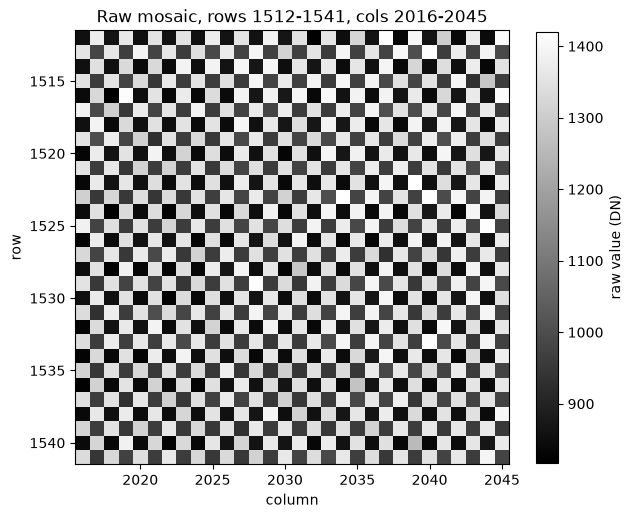

In [3]:
import matplotlib.pyplot as plt

n = 30
r0, c0 = mosaic.shape[0] // 2, mosaic.shape[1] // 2   # centre of the frame
patch = mosaic[r0:r0 + n, c0:c0 + n]

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(patch, cmap="gray", interpolation="nearest",
               extent=(c0 - 0.5, c0 + n - 0.5, r0 + n - 0.5, r0 - 0.5))
ax.set_title(f"Raw mosaic, rows {r0}-{r0 + n - 1}, cols {c0}-{c0 + n - 1}")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(im, ax=ax, label="raw value (DN)", shrink=0.8)
plt.show()

These are the pixels behind the red, green, and blue filters. The dark squares correspond to the blue pixels, the dark grey squares correspond to the red pixels, and the light grey squares correspond to the green pixels. 

### Problem 8: Name three things the camera's own pipeline did to the JPEG that cannot be undone afterwards, and say for each one why it is irreversible.
*Deliverable: a short written answer, three or four sentences.*

* Demosaicing: the pipeline interpolated the two missing colors at every pixel, so two-thirds of the output values are estimates. The HEIC file does not record which values were directly measured. 
* White balance and color conversion: the channels were scaled and mixed into a display color space, and values pushed past the maximum were clipped. Clipped values cannot be recovered.
* Noise reduction and sharpening: these are spatial filters that blend neighboring pixels. Fine texture smoothed away along with the noise cannot be distinguished from it afterward.

## First calibration captures

### Problem 9: Print the calibration target at 100% scale and tape it flat to card or board. Measure one square with a ruler and report the measured size in millimetres.
*Deliverable: the measured square size, and one sentence on why you will use your measured value rather than the nominal 20.0 mm.*

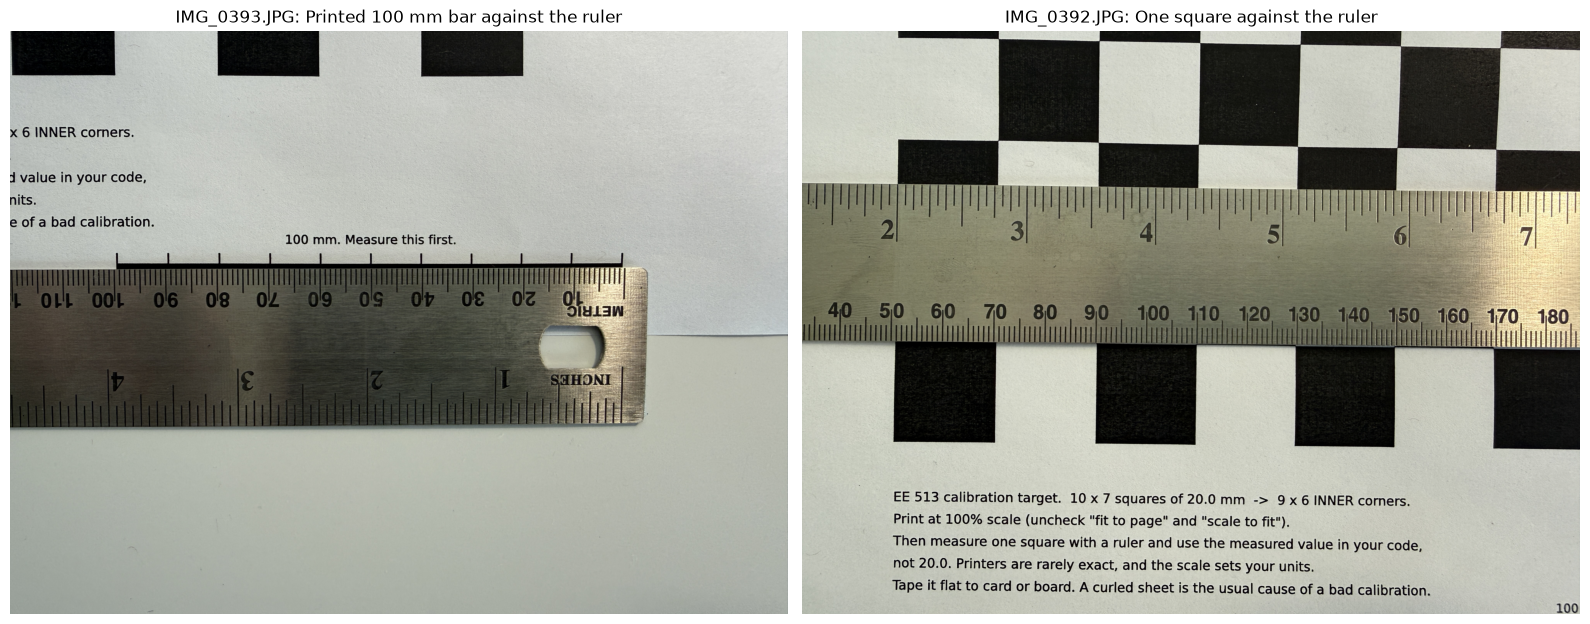

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

ruler_photos = {
    "IMG_0393.JPG": "Printed 100 mm bar against the ruler",
    "IMG_0392.JPG": "One square against the ruler",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, (name, caption) in zip(axes, ruler_photos.items()):
    img = ImageOps.exif_transpose(Image.open(Path("Image Captures") / name))
    ax.imshow(img)
    ax.set_title(f"{name}: {caption}")
    ax.axis("off")
fig.tight_layout()
plt.show()

Each square has 20mm sides. 

### Problem 10: Capture at least 15 photographs of the target at a variety of angles, distances, and positions in the frame, including several where the board is tilted well away from parallel and several where it sits near a corner of the frame.
*Deliverable: a contact sheet of your captures.*

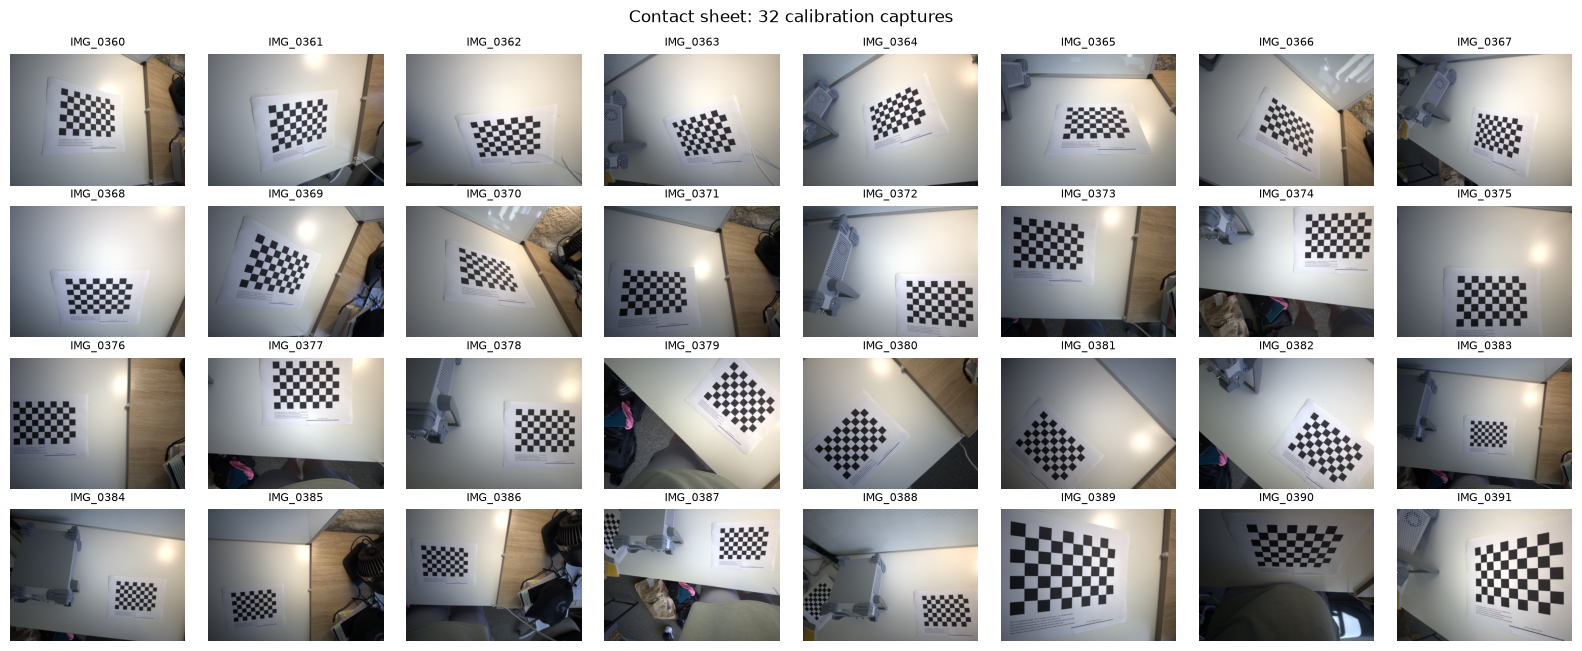

In [5]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import rawpy

cal_paths = [Path("Image Captures") / f"IMG_{i:04d}.DNG" for i in range(360, 392)]

PATTERN = (9, 6)     # inner corners
SCALE = 4            # detect on a 1/4-size copy, then refine at full resolution
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

thumbs, corners, drawn = [], {}, {}
for p in cal_paths:
    with rawpy.imread(str(p)) as raw:
        # user_flip=0 keeps every frame in sensor orientation, so all share one pixel grid
        rgb = raw.postprocess(use_camera_wb=True, user_flip=0)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    small = cv2.resize(gray, None, fx=1 / SCALE, fy=1 / SCALE, interpolation=cv2.INTER_AREA)
    thumbs.append(cv2.resize(rgb, None, fx=1 / 8, fy=1 / 8, interpolation=cv2.INTER_AREA))

    found, c = cv2.findChessboardCorners(small, PATTERN)
    if found:
        c = (c * SCALE + (SCALE - 1) / 2).astype(np.float32)   # back to full-res coordinates
        corners[p.name] = cv2.cornerSubPix(gray, c, (11, 11), (-1, -1), criteria)
        if not drawn:
            small_rgb = cv2.resize(rgb, None, fx=1 / SCALE, fy=1 / SCALE, interpolation=cv2.INTER_AREA)
            drawn[p.name] = cv2.drawChessboardCorners(
                small_rgb, PATTERN, (corners[p.name] - (SCALE - 1) / 2) / SCALE, True)

image_size = gray.shape[::-1]   # (width, height)

fig, axes = plt.subplots(4, 8, figsize=(16, 6.6))
for ax, p, t in zip(axes.flat, cal_paths, thumbs):
    ax.imshow(t)
    ax.set_title(p.stem, fontsize=8)
    ax.axis("off")
fig.suptitle(f"Contact sheet: {len(cal_paths)} calibration captures")
fig.tight_layout()
plt.show()

### Problem 11: Run cv2.findChessboardCorners with the pattern size (9, 6) on every capture and report how many succeeded.
*Deliverable: the count, and one image with the detected corners drawn on it.*

findChessboardCorners succeeded on 32 of 32 captures
Failed: none


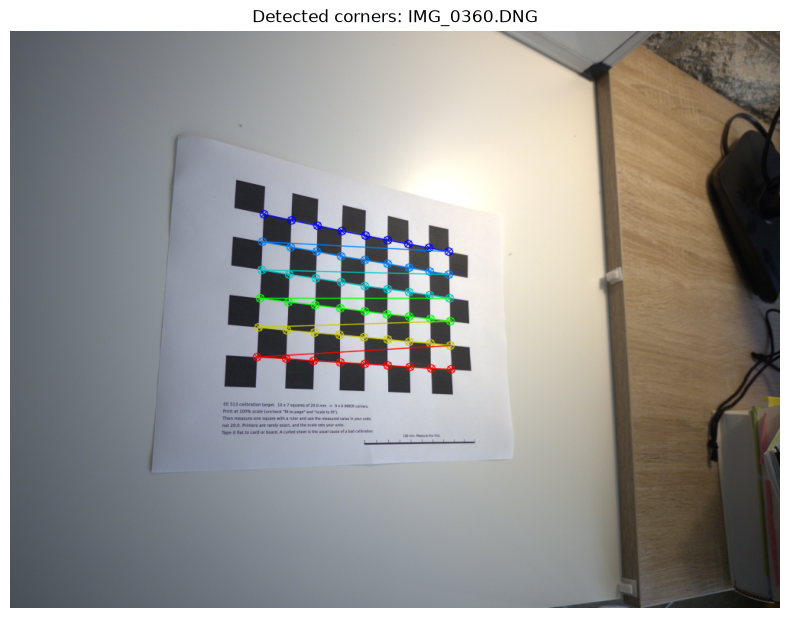

In [6]:
print(f"findChessboardCorners succeeded on {len(corners)} of {len(cal_paths)} captures")
failed = [p.name for p in cal_paths if p.name not in corners]
print("Failed:", failed if failed else "none")

name, img = next(iter(drawn.items()))
plt.figure(figsize=(10, 7.5))
plt.imshow(img)
plt.title(f"Detected corners: {name}")
plt.axis("off")
plt.show()

### Problem 12: Pass the successful detections to cv2.calibrateCamera and report the RMS reprojection error it returns. A rough number is fine here; Project 1 is where you will interpret it.
*Deliverable: the RMS reprojection error, and one sentence on what it means and what units it is in.*

In [7]:
SQUARE_MM = 20.0     # replace with your measured square size

objp = np.zeros((PATTERN[0] * PATTERN[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:PATTERN[0], 0:PATTERN[1]].T.reshape(-1, 2) * SQUARE_MM

img_points = list(corners.values())
obj_points = [objp] * len(img_points)

rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(obj_points, img_points, image_size, None, None)

print(f"Views used:             {len(img_points)}")
print(f"RMS reprojection error: {rms:.2f} px")
print(f"Camera matrix K:\n{np.round(K, 1)}")
print(f"Distortion (k1 k2 p1 p2 k3): {np.round(dist.ravel(), 4)}")

Views used:             32
RMS reprojection error: 1.23 px
Camera matrix K:
[[2.9186e+03 0.0000e+00 2.0454e+03]
 [0.0000e+00 2.9281e+03 1.5040e+03]
 [0.0000e+00 0.0000e+00 1.0000e+00]]
Distortion (k1 k2 p1 p2 k3): [ 2.061e-01 -7.750e-01 -4.000e-04  1.600e-03  8.339e-01]


### Problem 13: What did you learn from this assignment?
*Deliverable: a written response.*


I learned about the difference between JPEG and HEIC images and RAW images. I also learned that per-pixel information could be extracted from RAW images (reference to Problem 7). 

### Problem 14: What questions, if any, do you have for me after completing this assignment?
*Deliverable: a written response.*

I have no questions at this time. 

### AI Use:

AI was used in the following ways: 
* Code was generated using AI
* Answers for Problems 7 and 8 were checked using AI.
* Sources for Problems 7 and 8 were found using AI.
* Errors and exceptions while coding were explained using AI. Solutions were proposed by AI.
* Validity of answers for all problems was checked using AI. 